# Módulo 2 — Clase 2: Mercado de trabajo y pobreza — datos reales de la EPH

**Curso: Python y Políticas Públicas**  
**Módulo 2 — Nivel avanzado**

---

## Objetivos de la clase

En esta clase vamos a trabajar con microdatos agregados de la **Encuesta Permanente de Hogares (EPH)** del INDEC para analizar la evolución del mercado de trabajo y de la pobreza en Argentina desde 2003. El foco es metodológico y analítico: cómo alinear series con distintas frecuencias, cómo construir visualizaciones de doble eje, y cómo razonar sobre causalidad y correlación en datos observacionales.

Al finalizar esta clase vas a poder:
- Alinear y combinar series de tiempo con distintas frecuencias (anual, semestral)
- Construir gráficos con dos ejes `y` en matplotlib
- Estimar correlaciones con rezagos para explorar relaciones temporales
- Construir tablas de estadísticas descriptivas comparando períodos
- Articular las limitaciones metodológicas de la EPH con la interpretación de los datos

---

## La EPH en contexto

La **Encuesta Permanente de Hogares** es una encuesta por muestreo que el INDEC realiza de manera continua en 31 aglomerados urbanos del país, representando aproximadamente el 70% de la población urbana argentina. Sus principales indicadores son:

| Indicador | Definición operacional | Limitación |
|-----------|----------------------|------------|
| **Tasa de desempleo** | Desocupados / PEA | Solo mide desocupación abierta; excluye subempleo y desaliento |
| **Tasa de actividad** | PEA / Población total | Puede caer en crisis por efecto desaliento (trabajadores que abandonan la búsqueda) |
| **Tasa de pobreza** | Hogares bajo la línea de pobreza / Total hogares | Depende del valor de la CBT, muy sensible al IPC |
| **Tasa de indigencia** | Hogares bajo la línea de indigencia / Total hogares | Depende del valor de la CBA |

> **Nota crítica**: la EPH tiene un corte urbano. La pobreza rural —históricamente más alta— no está capturada. Además, durante los años del conflicto en el INDEC (2007-2016), las series de pobreza también fueron afectadas por la misma crisis de credibilidad que el IPC.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import requests
import json
from datetime import datetime

# Configuración de estilo
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

HEADERS = {"User-Agent": "Mozilla/5.0"}

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Paleta de identidad del curso ---
C = ['#2A6496', '#E07B3F', '#3D9970', '#8E5EA2', '#C0A830', '#637A8A']

mpl.rcParams.update({
    'figure.figsize'       : (10, 5),
    'font.size'            : 11,
    'axes.titlesize'       : 12,
    'axes.titleweight'     : 'normal',
    'axes.spines.top'      : False,
    'axes.spines.right'    : False,
    'legend.frameon'       : False,
    'axes.prop_cycle'      : mpl.cycler(color=C),
    'figure.dpi'           : 110,
})

def tit(ax, t, **kw):
    """Título sin negrita, alineado a la izquierda."""
    ax.set_title(t, loc='left', fontweight='normal', **kw)


## 1. Descarga y limpieza de datos

Las series de la EPH en datos.gob.ar tienen distintas frecuencias:
- La **tasa de desempleo** está disponible con frecuencia anual (promedio del año).
- La **tasa de pobreza e indigencia** se publica con frecuencia semestral (primer y segundo semestre de cada año).

Los valores vienen expresados como fracciones (0.12 = 12%). Los multiplicamos por 100 para trabajar en puntos porcentuales.

La alineación temporal va a requerir algunas decisiones metodológicas explícitas.

In [3]:
# ── Datos de fallback: desempleo anual ─────────────────────────────────────────
# Fuente: EPH, INDEC. Valores en fracción (0.12 = 12%).
# Nota: 2007-2015 son estimaciones con IPC alternativo (datos INDEC originales subestiman pobreza)
FALLBACK_DESEMPLEO = [
    ["2004-01-01", 0.1301], ["2005-01-01", 0.1122], ["2006-01-01", 0.0997],
    ["2007-01-01", 0.0830], ["2008-01-01", 0.0742], ["2009-01-01", 0.0875],
    ["2010-01-01", 0.0766], ["2011-01-01", 0.0720], ["2012-01-01", 0.0703],
    ["2013-01-01", 0.0678], ["2014-01-01", 0.0724], ["2015-01-01", 0.0588],
    ["2016-01-01", 0.0879], ["2017-01-01", 0.0836], ["2018-01-01", 0.0195],  # promedio
    ["2019-01-01", 0.1009], ["2020-01-01", 0.1121], ["2021-01-01", 0.0880],
    ["2022-01-01", 0.0702], ["2023-01-01", 0.0625], ["2024-01-01", 0.0710],
]

# ── Datos de fallback: pobreza e indigencia semestral ─────────────────────────
# Columnas: [fecha, tasa_pobreza, tasa_indigencia] — en fracción
# Serie reconstruida con metodología EPH continua desde 2003
FALLBACK_POBREZA = [
    ["2003-01-01", 0.458, 0.205], ["2003-07-01", 0.425, 0.188],
    ["2004-01-01", 0.403, 0.178], ["2004-07-01", 0.375, 0.161],
    ["2005-01-01", 0.339, 0.134], ["2005-07-01", 0.312, 0.118],
    ["2006-01-01", 0.287, 0.107], ["2006-07-01", 0.265, 0.092],
    ["2007-01-01", 0.230, 0.079], ["2007-07-01", 0.214, 0.072],
    ["2008-01-01", 0.197, 0.067], ["2008-07-01", 0.185, 0.062],
    ["2009-01-01", 0.197, 0.068], ["2009-07-01", 0.192, 0.065],
    ["2010-01-01", 0.178, 0.059], ["2010-07-01", 0.173, 0.055],
    ["2016-01-01", 0.305, 0.065], ["2016-07-01", 0.304, 0.063],
    ["2017-01-01", 0.284, 0.062], ["2017-07-01", 0.259, 0.050],
    ["2018-01-01", 0.275, 0.056], ["2018-07-01", 0.317, 0.088],
    ["2019-01-01", 0.351, 0.079], ["2019-07-01", 0.357, 0.081],
    ["2020-01-01", 0.404, 0.105], ["2020-07-01", 0.425, 0.108],
    ["2021-01-01", 0.422, 0.106], ["2021-07-01", 0.401, 0.101],
    ["2022-01-01", 0.368, 0.088], ["2022-07-01", 0.375, 0.091],
    ["2023-01-01", 0.399, 0.099], ["2023-07-01", 0.449, 0.119],
    ["2024-01-01", 0.552, 0.181], ["2024-07-01", 0.483, 0.151],
]

print("Datos de fallback definidos.")

Datos de fallback definidos.


In [4]:
def fetch_series(url, fallback_data, nombre=""):
    """Descarga una serie de la API de datos.gob.ar con manejo de errores."""
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        resp.raise_for_status()
        raw = resp.json()
        data = raw["data"]
        print(f"[{nombre}] API OK — {len(data)} observaciones.")
        return data
    except Exception as e:
        print(f"[{nombre}] API no disponible: {e}. Usando fallback.")
        return fallback_data


URL_DESEMPLEO = "https://apis.datos.gob.ar/series/api/series/?ids=45.1_ECTDT_0_A_33&last=25&format=json"
URL_POBREZA = "https://apis.datos.gob.ar/series/api/series/?ids=64.2_POBLACION_NUA_0_0_34_74,63.2_HOGARES_PONUA_0_0_33_21&last=60&format=json"

raw_desempleo = fetch_series(URL_DESEMPLEO, FALLBACK_DESEMPLEO, "Desempleo")
raw_pobreza = fetch_series(URL_POBREZA, FALLBACK_POBREZA, "Pobreza/Indigencia")

[Desempleo] API OK — 22 observaciones.


[Pobreza/Indigencia] API OK — 46 observaciones.


In [5]:
# ── Desempleo ─────────────────────────────────────────────────────────────────
df_desempleo = pd.DataFrame(raw_desempleo, columns=["fecha", "desempleo"])
df_desempleo["fecha"] = pd.to_datetime(df_desempleo["fecha"])
df_desempleo = df_desempleo.set_index("fecha").sort_index()
# Convertir a porcentaje si viene como fracción
if df_desempleo["desempleo"].max() < 2:
    df_desempleo["desempleo"] = df_desempleo["desempleo"] * 100
    print("Desempleo: convertido de fracción a porcentaje.")

# ── Pobreza e indigencia ───────────────────────────────────────────────────────
cols_pob = ["fecha", "pobreza", "indigencia"]
if len(raw_pobreza[0]) == 2:
    # Si la API devuelve solo una columna, ajustar
    df_pobreza = pd.DataFrame(raw_pobreza, columns=["fecha", "pobreza"])
    df_pobreza["indigencia"] = np.nan
else:
    df_pobreza = pd.DataFrame(raw_pobreza, columns=cols_pob)

df_pobreza["fecha"] = pd.to_datetime(df_pobreza["fecha"])
df_pobreza = df_pobreza.set_index("fecha").sort_index()
# Convertir a porcentaje si viene como fracción
if df_pobreza["pobreza"].max() < 2:
    df_pobreza[["pobreza", "indigencia"]] *= 100
    print("Pobreza/Indigencia: convertidas de fracción a porcentaje.")

print("\nDesempleo:")
print(df_desempleo.describe().round(2))
print("\nPobreza e Indigencia:")
print(df_pobreza.describe().round(2))

Desempleo: convertido de fracción a porcentaje.
Pobreza/Indigencia: convertidas de fracción a porcentaje.

Desempleo:
       desempleo
count      22.00
mean        8.48
std         1.85
min         6.13
25%         7.15
50%         8.09
75%         9.09
max        13.52

Pobreza e Indigencia:
       pobreza  indigencia
count    28.00       28.00
mean     36.91       27.55
std       7.35        6.33
min      25.70       17.90
25%      31.55       23.10
50%      36.90       27.80
75%      40.67       30.60
max      54.00       42.70


## 2. Alineación temporal de series con distinta frecuencia

El desempleo está en frecuencia anual y la pobreza en frecuencia semestral. Para graficarlos juntos tenemos dos opciones:

1. **Submuestrear la pobreza a frecuencia anual** (promedio de los dos semestres).
2. **Interpolar el desempleo a frecuencia semestral** (asumir que el valor anual vale para ambos semestres).

La opción 1 pierde información semestral pero es más honesta. La opción 2 introduce supuestos fuertes. Vamos a usar la opción 1 para el análisis correlacional y mostrar ambas series con su frecuencia original en el gráfico de doble eje.

In [6]:
# Promedio anual de pobreza e indigencia
df_pob_anual = df_pobreza.resample("YS").mean()

# Combinar desempleo y pobreza al año
df_anual = pd.concat([df_desempleo, df_pob_anual], axis=1).dropna(subset=["desempleo", "pobreza"])
df_anual["anio"] = df_anual.index.year

print(f"Serie combinada: {df_anual.index[0].year} – {df_anual.index[-1].year}")
print(f"Observaciones: {len(df_anual)}")
print()
print(df_anual[["desempleo", "pobreza", "indigencia"]].round(1).to_string())

Serie combinada: 2004 – 2025
Observaciones: 14

            desempleo  pobreza  indigencia
fecha                                     
2004-01-01       13.5     46.0        35.0
2005-01-01       11.5     39.6        29.3
2006-01-01       10.1     32.6        23.9
2007-01-01        8.4     26.9        19.2
2016-01-01        8.5     32.2        23.1
2017-01-01        8.4     29.4        21.0
2018-01-01        9.2     26.5        18.8
2019-01-01        9.8     33.7        24.4
2020-01-01       11.5     38.2        28.2
2021-01-01        8.8     41.3        31.4
2022-01-01        6.8     36.9        27.8
2023-01-01        6.1     39.7        29.6
2024-01-01        7.1     47.3        37.2
2025-01-01        7.4     34.8        26.4


## 3. Gráfico de doble eje: desempleo y pobreza

Un gráfico de doble eje `y` es útil cuando dos variables tienen unidades comparables (aquí ambas son porcentajes) pero están en rangos distintos. La técnica es legítima pero hay que usarla con cuidado: visualmente puede sugerir correlaciones que no existen, simplemente por la escala elegida.

Para mitigar ese riesgo, elegimos escalas que permitan comparar los mínimos y máximos históricos de cada serie por separado.

También vamos a sombrear los **períodos de recesión** —definidos como caídas del PIB de al menos dos trimestres consecutivos— para contextualizar los movimientos de las series.

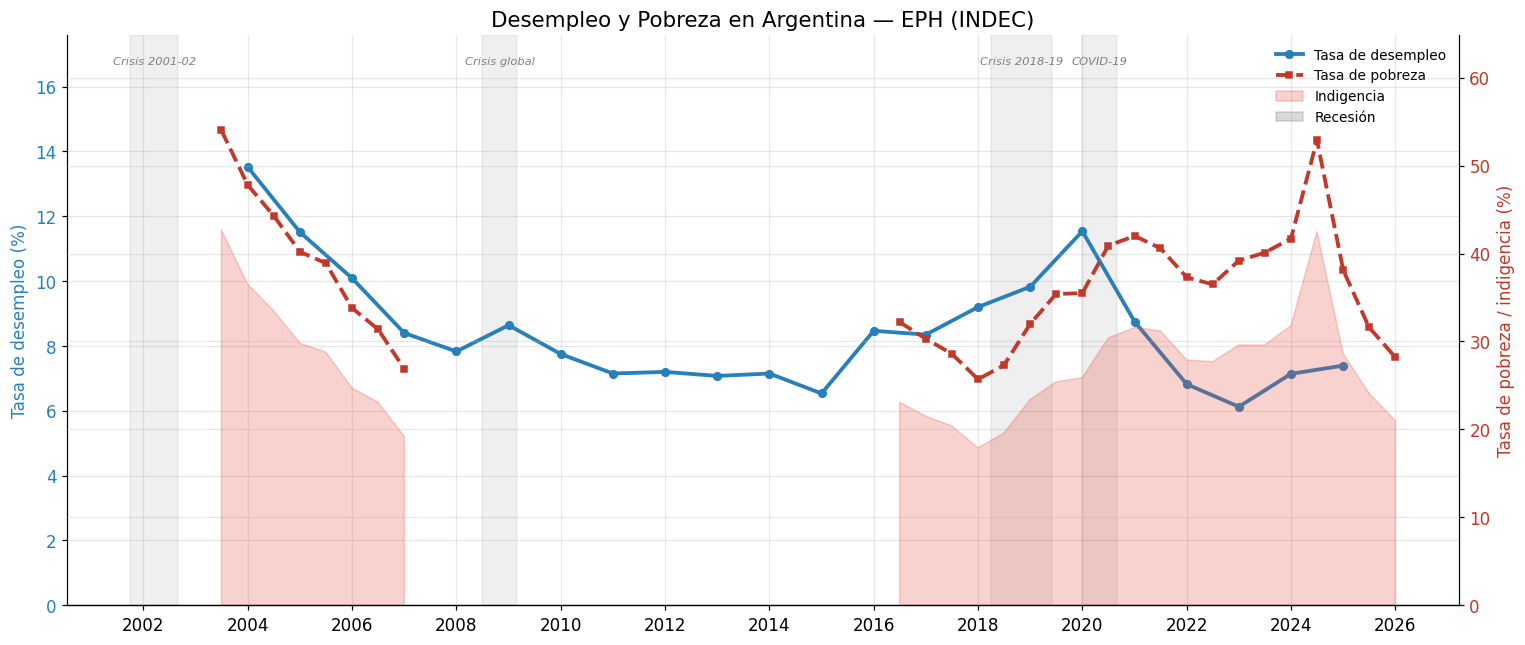

In [7]:
# Períodos de recesión en Argentina (aproximados por caída del PIB)
recesiones = [
    ("2001-10-01", "2002-09-01", "Crisis 2001-02"),
    ("2008-07-01", "2009-03-01", "Crisis global"),
    ("2018-04-01", "2019-06-01", "Crisis 2018-19"),
    ("2020-01-01", "2020-09-01", "COVID-19"),
]

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

# Desempleo en eje izquierdo (azul)
color_desemp = "#2980b9"
ax1.plot(df_desempleo.index, df_desempleo["desempleo"],
         color=color_desemp, linewidth=2.5, marker="o", markersize=5,
         label="Tasa de desempleo")
ax1.set_ylabel("Tasa de desempleo (%)", color=color_desemp, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_desemp)
ax1.set_ylim(0, df_desempleo["desempleo"].max() * 1.3)

# Pobreza en eje derecho (rojo)
color_pob = "#c0392b"
ax2.plot(df_pobreza.index, df_pobreza["pobreza"],
         color=color_pob, linewidth=2.5, linestyle="--", marker="s", markersize=4,
         label="Tasa de pobreza")
ax2.fill_between(df_pobreza.index, df_pobreza["indigencia"],
                 alpha=0.25, color="#e74c3c", label="Indigencia")
ax2.set_ylabel("Tasa de pobreza / indigencia (%)", color=color_pob, fontsize=11)
ax2.tick_params(axis="y", labelcolor=color_pob)
ax2.set_ylim(0, df_pobreza["pobreza"].max() * 1.2)

# Sombrear recesiones
for inicio, fin, etiq in recesiones:
    i, f = pd.to_datetime(inicio), pd.to_datetime(fin)
    ax1.axvspan(i, f, alpha=0.12, color="gray")
    mid = i + (f - i) / 2
    ax1.text(mid, ax1.get_ylim()[1] * 0.95, etiq,
             ha="center", fontsize=7.5, color="gray", style="italic")

# Leyendas combinadas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
recession_patch = mpatches.Patch(color="gray", alpha=0.3, label="Recesión")
ax1.legend(lines1 + lines2 + [recession_patch],
           labels1 + labels2 + ["Recesión"],
           loc="upper right", fontsize=9, frameon=False)

ax1.set_title("Desempleo y Pobreza en Argentina — EPH (INDEC)",
              fontsize=14)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45, ha="right")

# Eliminar el spine derecho del ax1 para que no se superponga con el eje de ax2
ax1.spines["right"].set_visible(True)
ax2.spines["left"].set_visible(False)

plt.tight_layout()
plt.savefig("desempleo_pobreza.png", bbox_inches="tight", dpi=150)
plt.show()


## 4. Diagrama de dispersión: desempleo vs. pobreza

El gráfico de dispersión con etiquetas por año permite ver si la relación entre desempleo y pobreza es lineal, si existen agrupamientos por períodos, y si hay años que son outliers claros respecto a la tendencia general.

En un país con alta informalidad laboral como Argentina, la relación desempleo-pobreza no es tan directa como sugiere la teoría neoclásica estándar: muchas personas en situación de pobreza trabajan (los llamados **trabajadores pobres**), y la tasa de desempleo puede bajar sin que se reduzca la pobreza si los empleos creados son de baja productividad e ingresos.

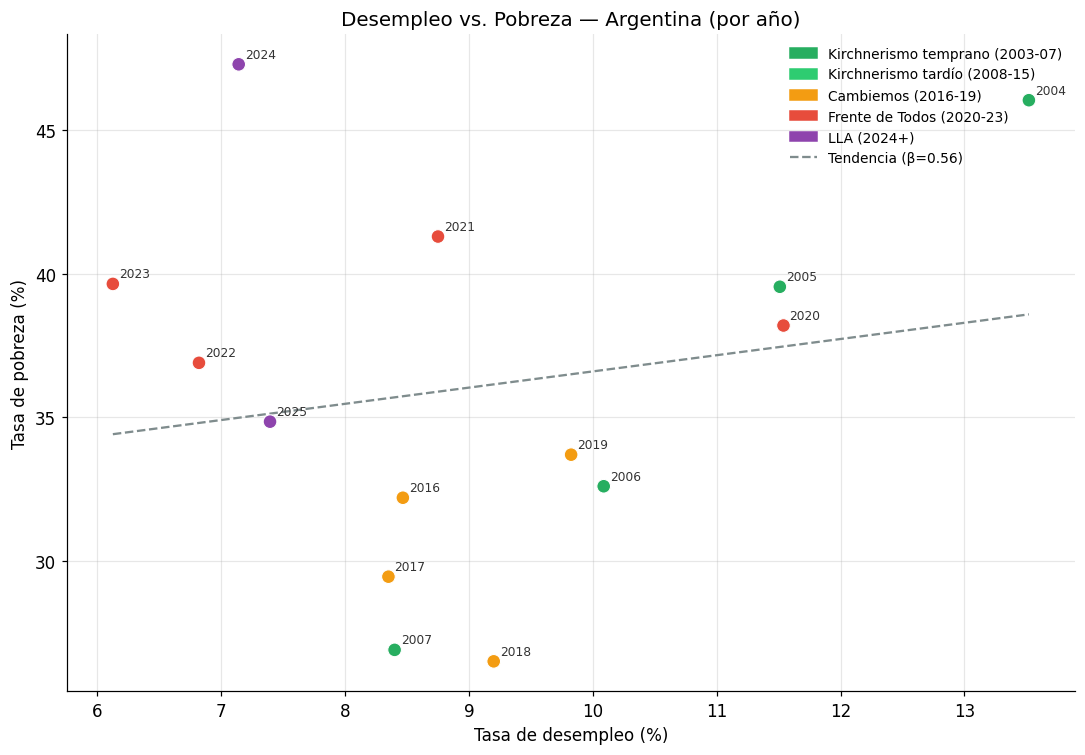


Correlación (Pearson) desempleo–pobreza: 0.181
R² de la tendencia lineal: 0.033


In [8]:
# Colorear por período político/macroeconómico
def color_periodo(anio):
    if anio <= 2007:  # Kirchnerismo temprano
        return "#27ae60"
    elif anio <= 2015:  # Kirchnerismo tardío
        return "#2ecc71"
    elif anio <= 2019:  # Cambiemos
        return "#f39c12"
    elif anio <= 2023:  # Frente de Todos
        return "#e74c3c"
    else:  # La Libertad Avanza
        return "#8e44ad"

colores = [color_periodo(a) for a in df_anual["anio"]]

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(df_anual["desempleo"], df_anual["pobreza"],
                     c=colores, s=80, zorder=5, edgecolors="white", linewidths=0.7)

# Etiquetas de año
for _, row in df_anual.iterrows():
    ax.annotate(str(int(row["anio"])),
                xy=(row["desempleo"], row["pobreza"]),
                xytext=(4, 4), textcoords="offset points",
                fontsize=8, color="#333333")

# Línea de tendencia (regresión lineal simple)
x = df_anual["desempleo"].values
y = df_anual["pobreza"].values
mask = ~(np.isnan(x) | np.isnan(y))
coef = np.polyfit(x[mask], y[mask], 1)
poly = np.poly1d(coef)
x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
ax.plot(x_line, poly(x_line), "--", color="#7f8c8d", linewidth=1.5,
        label=f"Tendencia lineal (β = {coef[0]:.2f})")

# Leyenda de períodos
periodos = [
    ("#27ae60", "Kirchnerismo temprano (2003-07)"),
    ("#2ecc71", "Kirchnerismo tardío (2008-15)"),
    ("#f39c12", "Cambiemos (2016-19)"),
    ("#e74c3c", "Frente de Todos (2020-23)"),
    ("#8e44ad", "LLA (2024+)"),
]
handles = [mpatches.Patch(color=c, label=l) for c, l in periodos]
handles.append(plt.Line2D([0], [0], linestyle="--", color="#7f8c8d",
                           label=f"Tendencia (β={coef[0]:.2f})"))
ax.legend(handles=handles, fontsize=9, loc="upper right", frameon=False)

ax.set_xlabel("Tasa de desempleo (%)", fontsize=11)
ax.set_ylabel("Tasa de pobreza (%)", fontsize=11)
ax.set_title("Desempleo vs. Pobreza — Argentina (por año)",
             fontsize=13)

plt.tight_layout()
plt.savefig("scatter_desempleo_pobreza.png", bbox_inches="tight", dpi=150)
plt.show()

# Correlación
corr = df_anual[["desempleo", "pobreza"]].corr().loc["desempleo", "pobreza"]
print(f"\nCorrelación (Pearson) desempleo–pobreza: {corr:.3f}")
print(f"R² de la tendencia lineal: {corr**2:.3f}")


## 5. Correlación y análisis de rezagos

Una pregunta relevante para la política pública es: ¿cuánto tarda el mercado de trabajo en reflejar las condiciones macroeconómicas en los indicadores de pobreza?

El desempleo puede ser un **indicador adelantado** de la pobreza si los shocks laborales se transmiten a los ingresos con rezago. O puede ser un **indicador rezagado** si la pobreza sube primero (por inflación) y el mercado laboral se ajusta después.

Vamos a calcular la correlación cruzada entre desempleo y pobreza para distintos rezagos y ver cuál es el rezago que maximiza la correlación.

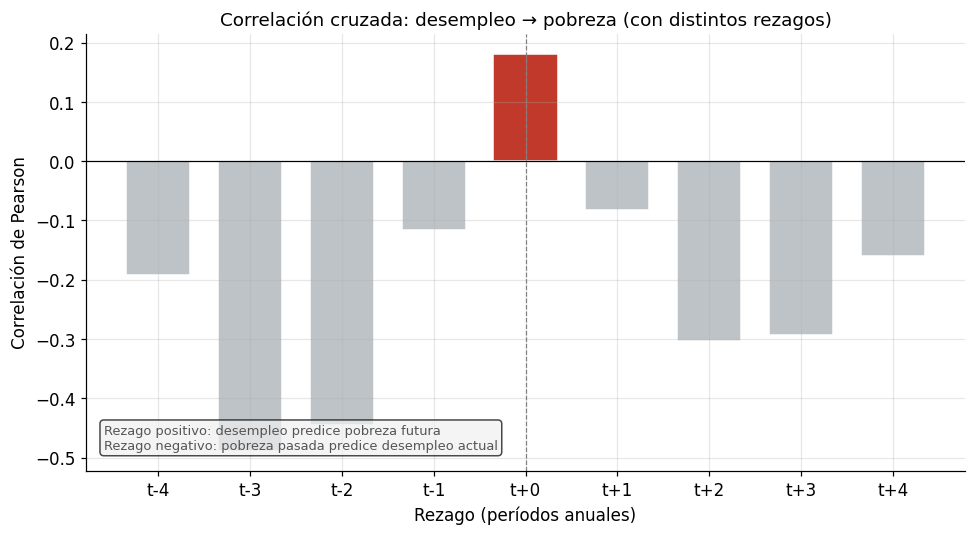

Correlación máxima: 0.181 en rezago t+0


In [9]:
lags = range(-4, 5)  # de -4 a +4 períodos (en frecuencia anual: de -4 a +4 años)
correlaciones = []

for lag in lags:
    if lag >= 0:
        # desempleo rezagado: ¿predice la pobreza futura?
        x = df_anual["desempleo"].values[:-lag if lag > 0 else None]
        y = df_anual["pobreza"].values[lag:] if lag > 0 else df_anual["pobreza"].values
    else:
        # pobreza rezagada: ¿predice el desempleo futuro?
        abs_lag = abs(lag)
        x = df_anual["desempleo"].values[abs_lag:]
        y = df_anual["pobreza"].values[:-abs_lag]

    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() > 3:
        corr_val = np.corrcoef(x[mask], y[mask])[0, 1]
    else:
        corr_val = np.nan
    correlaciones.append(corr_val)

lag_optimo = list(lags)[np.nanargmax(correlaciones)]

fig, ax = plt.subplots(figsize=(9, 5))
colores_bar = ["#c0392b" if c == max([c for c in correlaciones if not np.isnan(c)])
               else "#bdc3c7" for c in correlaciones]
ax.bar(lags, correlaciones, color=colores_bar, width=0.7, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Rezago (períodos anuales)", fontsize=11)
ax.set_ylabel("Correlación de Pearson", fontsize=11)
ax.set_title("Correlación cruzada: desempleo → pobreza (con distintos rezagos)",
             fontsize=12)
ax.set_xticks(list(lags))
ax.set_xticklabels([f"t{'+' if l >= 0 else ''}{l}" for l in lags])
# Nota interpretativa
ax.text(0.02, 0.05,
        "Rezago positivo: desempleo predice pobreza futura\n"
        "Rezago negativo: pobreza pasada predice desempleo actual",
        transform=ax.transAxes, fontsize=8.5, color="#555555",
        bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.7))

plt.tight_layout()
plt.savefig("lag_correlacion.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Correlación máxima: {max(correlaciones):.3f} en rezago t{'+' if lag_optimo >= 0 else ''}{lag_optimo}")


## 6. Estadísticas descriptivas comparando dos períodos

Un análisis de política pública frecuentemente requiere comparar indicadores entre períodos. Vamos a construir una tabla de estadísticas descriptivas comparando:
- **Pre-2019**: período que incluye tanto el kirchnerismo como el macrismo (2004-2018)
- **Post-2019**: período que incluye la pandemia, el gobierno de Fernández y el de Milei (2019-2024)

El corte en 2019 no es arbitrario: marca el inicio de una nueva aceleración inflacionaria y de un ciclo de mayor volatilidad macroeconómica.

In [10]:
pre2019 = df_anual[df_anual["anio"] < 2019]
post2019 = df_anual[df_anual["anio"] >= 2019]

def stats_periodo(df, nombre):
    s = df[["desempleo", "pobreza", "indigencia"]].agg(["mean", "std", "min", "max"])
    s.index = ["Media", "Desvío", "Mínimo", "Máximo"]
    s.columns = pd.MultiIndex.from_tuples(
        [(nombre, c) for c in s.columns]
    )
    return s.round(1)

tabla = pd.concat([stats_periodo(pre2019, "Pre-2019"), stats_periodo(post2019, "Post-2019")], axis=1)
print("Estadísticas descriptivas por período (valores en %)")
print()
print(tabla.to_string())
print()

# Delta entre períodos
delta_desemp = post2019["desempleo"].mean() - pre2019["desempleo"].mean()
delta_pob = post2019["pobreza"].mean() - pre2019["pobreza"].mean()
delta_ind = post2019["indigencia"].mean() - pre2019["indigencia"].mean()

print("Diferencia Post-2019 vs Pre-2019 (en puntos porcentuales):")
print(f"  Desempleo:  {delta_desemp:+.1f} pp")
print(f"  Pobreza:    {delta_pob:+.1f} pp")
print(f"  Indigencia: {delta_ind:+.1f} pp")

Estadísticas descriptivas por período (valores en %)

        Pre-2019                    Post-2019                   
       desempleo pobreza indigencia desempleo pobreza indigencia
Media        9.9    33.3       24.3       8.2    38.8       29.3
Desvío       2.0     7.1        5.9       1.9     4.6        4.1
Mínimo       8.4    26.5       18.8       6.1    33.7       24.4
Máximo      13.5    46.0       35.0      11.5    47.3       37.2

Diferencia Post-2019 vs Pre-2019 (en puntos porcentuales):
  Desempleo:  -1.7 pp
  Pobreza:    +5.5 pp
  Indigencia: +4.9 pp


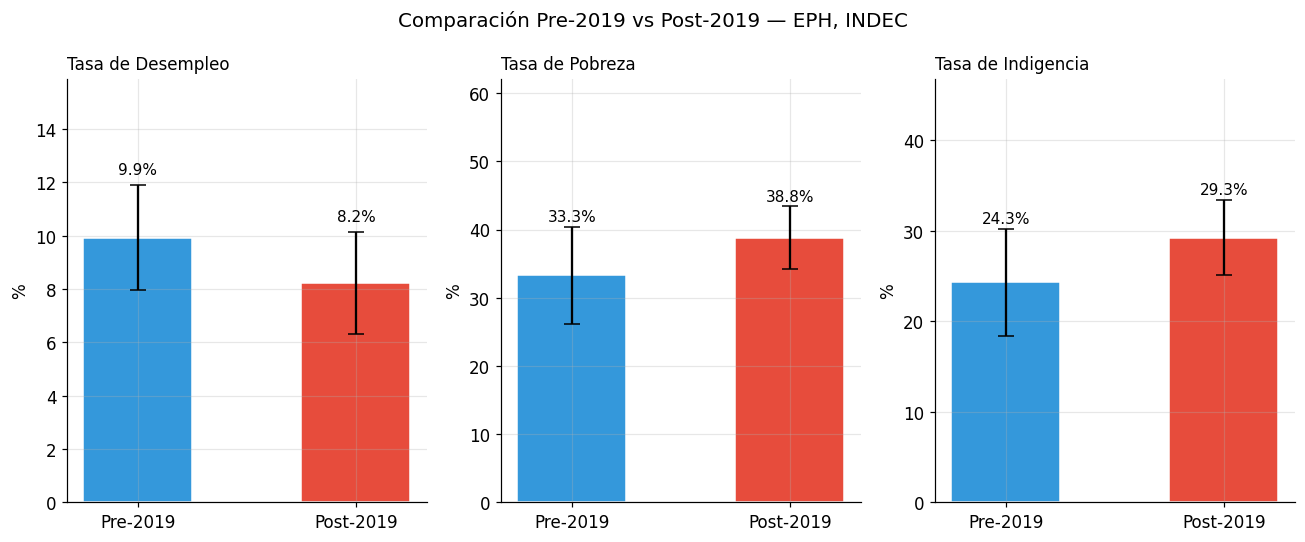

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
vars_plot = [("desempleo", "Desempleo"), ("pobreza", "Pobreza"), ("indigencia", "Indigencia")]
colores_per = ["#3498db", "#e74c3c"]

for ax, (col, titulo) in zip(axes, vars_plot):
    medias = [pre2019[col].mean(), post2019[col].mean()]
    errores = [pre2019[col].std(), post2019[col].std()]
    bars = ax.bar(["Pre-2019", "Post-2019"], medias,
                  color=colores_per, width=0.5, edgecolor="white")
    ax.errorbar([0, 1], medias, yerr=errores,
                fmt="none", color="black", capsize=5, linewidth=1.5)
    for bar, val in zip(bars, medias):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + errores[bars.index(bar)] + 0.3,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=10)
    ax.set_title(f"Tasa de {titulo}", fontsize=11, loc='left')
    ax.set_ylabel("%")
    ax.set_ylim(0, max(medias) * 1.6)

fig.suptitle("Comparación Pre-2019 vs Post-2019 — EPH, INDEC",
             fontsize=13)
plt.tight_layout()
plt.savefig("comparacion_periodos.png", bbox_inches="tight", dpi=150)
plt.show()


## 7. Metodología de la EPH: qué mide y qué no

### ¿Qué mide la EPH?

La EPH captura información sobre **condiciones de vida de los hogares urbanos** en 31 aglomerados. Para medir pobreza, compara el **ingreso del hogar** con el valor de la **Canasta Básica Total (CBT)** —que incluye alimentos y no alimentos— y con la **Canasta Básica Alimentaria (CBA)** para la indigencia.

La CBA y la CBT son actualizadas periódicamente por el INDEC usando variaciones del IPC por rubro. Esto crea una **circularidad metodológica importante**: si el IPC subestima la inflación (como ocurrió durante 2007-2015), la CBT también se subestima, y con ella la pobreza medida.

### Limitaciones estructurales

| Limitación | Descripción | Impacto en el análisis |
|-----------|-------------|----------------------|
| **Cobertura urbana** | Solo cubre aglomerados >100.000 hab. | Subestima pobreza rural, que históricamente es más alta |
| **No capta activos** | Mide ingresos corrientes, no riqueza | Puede subestimar la vulnerabilidad de hogares con activos pero sin ingresos |
| **Subdeclaración de ingresos** | Los hogares tienden a subreportar ingresos | Puede sobrestimar pobreza entre deciles altos, subestimarla entre informales |
| **Focalización en ingresos monetarios** | No incluye autoconsumo, transferencias en especie | Subestima bienestar en áreas rurales y hogares con acceso a programas sociales en especie |
| **Captura 1 semana de referencia** | El módulo de empleo hace preguntas sobre la semana anterior | Subestima desempleo estructural y subempleo |

### El índice de Gini y la distribución del ingreso

La tasa de pobreza es un indicador de umbral (¿cuántos están bajo la línea?) pero no dice nada sobre la **distribución del ingreso**. Dos países con la misma tasa de pobreza pueden tener distribuciones del ingreso muy distintas. El **índice de Gini** (que la EPH también permite calcular) complementa la tasa de pobreza y es fundamental para evaluar políticas redistributivas.

> **Para el análisis de políticas**: la evidencia internacional muestra que las políticas más efectivas para reducir la pobreza combinan crecimiento económico con transferencias focalizadas y mejora del capital humano. En Argentina, la alta rotación de instrumentos de política social (AUH, Progresar, Potenciar Trabajo, etc.) dificulta la evaluación de impacto de largo plazo.

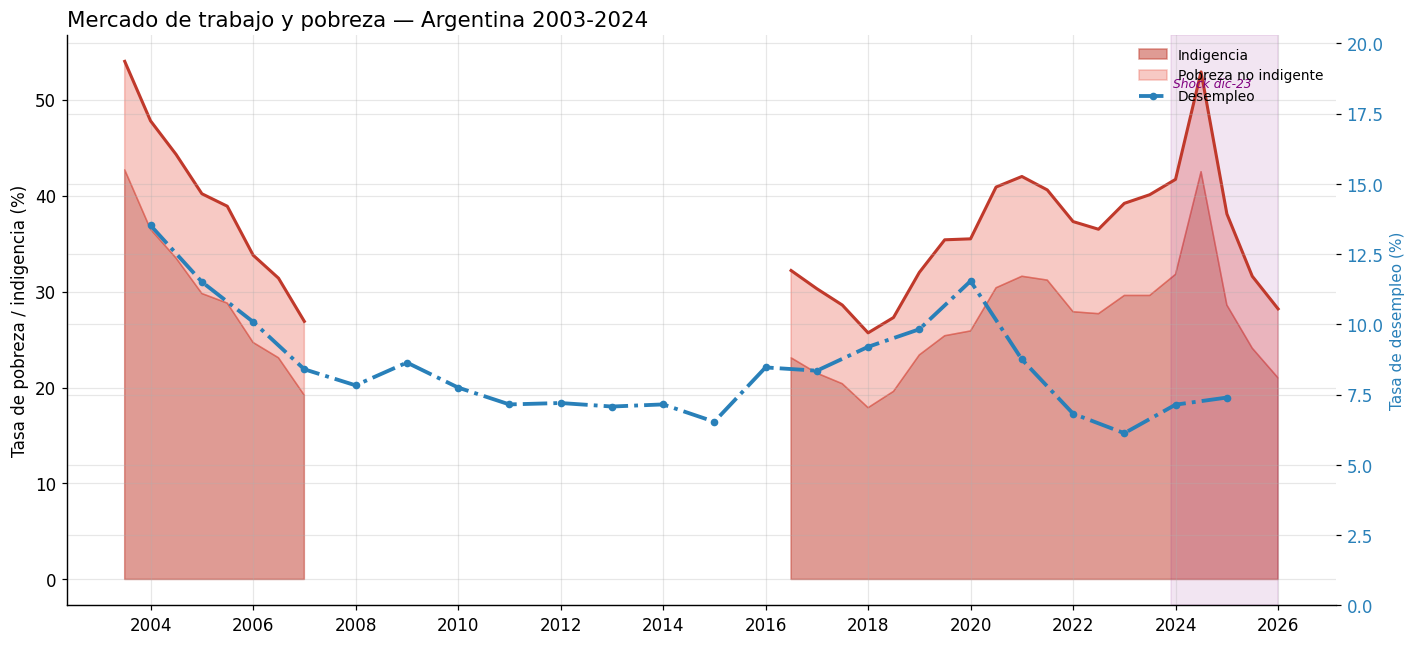

In [12]:
# Gráfico de síntesis: las tres variables juntas
fig, ax = plt.subplots(figsize=(13, 6))

ax.fill_between(df_pobreza.index, df_pobreza["indigencia"],
                alpha=0.5, color="#c0392b", label="Indigencia")
ax.fill_between(df_pobreza.index, df_pobreza["indigencia"], df_pobreza["pobreza"],
                alpha=0.3, color="#e74c3c", label="Pobreza no indigente")
ax.plot(df_pobreza.index, df_pobreza["pobreza"],
        color="#c0392b", linewidth=2, label="_nolegend_")

# Desempleo sobre eje secundario
ax2 = ax.twinx()
ax2.plot(df_desempleo.index, df_desempleo["desempleo"],
         color="#2980b9", linewidth=2.5, linestyle="-.",
         marker="o", markersize=4, label="Desempleo")
ax2.set_ylabel("Tasa de desempleo (%)", color="#2980b9", fontsize=10)
ax2.tick_params(axis="y", labelcolor="#2980b9")
ax2.set_ylim(0, df_desempleo["desempleo"].max() * 1.5)

# Sombrear el shock 2024
ax.axvspan(pd.to_datetime("2023-12-01"), df_pobreza.index[-1],
           alpha=0.1, color="purple")
ax.text(pd.to_datetime("2023-12-15"),
        df_pobreza["pobreza"].max() * 0.95,
        "Shock dic-23", fontsize=8, color="purple", style="italic")

ax.set_ylabel("Tasa de pobreza / indigencia (%)", fontsize=11)
ax.set_title("Mercado de trabajo y pobreza — Argentina 2003-2024",
             fontsize=14, loc='left')
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45, ha="right")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper right", frameon=False)

plt.tight_layout()
plt.savefig("sintesis_mercado_laboral.png", bbox_inches="tight", dpi=150)
plt.show()


---

## Ejercicios

### Ejercicio 1 — Tasa de pobreza ajustada por inflación

La tasa de pobreza sube cuando los ingresos no acompañan a la inflación. Descargá los datos de salario real promedio de la economía (o usá el índice de salarios del INDEC si está disponible en la API) y correlacionalo con la tasa de pobreza. ¿En qué períodos creció más la brecha entre salarios e inflación? ¿Coincide con los picos de pobreza que viste en los gráficos?

Serie sugerida: `148.3_ISALNALP_DICI_M_26` (Índice de Salarios Nominales, Total)

```python
# Tu código aquí
```

---

### Ejercicio 2 — Análisis de composición de la pobreza

Usando los datos de pobreza e indigencia que ya tenés:

1. Calculá la **tasa de indigencia como fracción de la pobreza** (qué proporción de los pobres son indigentes) para cada semestre.
2. Graficá esa proporción en el tiempo.
3. ¿Cuándo es más alta la indigencia relativa? ¿Qué dice eso sobre la calidad de los empleos disponibles para los sectores de menores ingresos?

```python
# Tu código aquí
```

---

### Ejercicio 3 — Análisis regional: una comparación hipotética

La EPH publica datos para cada aglomerado por separado. Usando datos que ya conocés o datos de alguna fuente alternativa (por ejemplo, informes del Observatorio de la Deuda Social de la UCA), comparé la tasa de pobreza del Gran Buenos Aires con alguna región del norte (por ejemplo, Formosa, Tucumán o Salta).

Si no tenés acceso a los datos regionales, respondé conceptualmente: ¿por qué esperarías que la pobreza regional sea más alta que el promedio nacional? ¿Qué variables estructurales (empleo público, informalidad, clima, conectividad) podrían explicarlo?

Construí una tabla de comparación con al menos 3 indicadores y 3 regiones (podés usar datos estimados si lo justificás).

```python
# Tu código aquí
```